In [38]:
import pandas as pd
import matplotlib.pyplot as plt

from feature_eng_functions import drop_unnecessary, occupation_mapping, summarize_workclass
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
base_adult = pd.read_csv(filepath_or_buffer="adult\\adult.data")
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
base_adult.drop(base_adult.loc[base_adult.workclass == " ?"].index, inplace=True)

In [4]:
base_adult.drop(base_adult.loc[base_adult.occupation == " ?"].index, inplace=True)

In [5]:
base_adult["occupation"] = base_adult["occupation"].apply(func=occupation_mapping)
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Office-Worker,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Office-Worker,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Manual-Worker,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Manual-Worker,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Office-Worker,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Office-Worker,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machinery-Worker,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Office-Worker,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Office-Worker,Own-child,White,Male,0,0,20,United-States,<=50K


In [6]:
#base_adult["workclass"] = base_adult["workclass"].apply(func=summarize_workclass)

In [7]:
base_adult = drop_unnecessary(df=base_adult)
base_adult

,age,workclass,fnlwgt,education-num,occupation,income
0,39,State-gov,77516,13,Office-Worker,<=50K
1,50,Self-emp-not-inc,83311,13,Office-Worker,<=50K
2,38,Private,215646,9,Manual-Worker,<=50K
3,53,Private,234721,7,Manual-Worker,<=50K
4,28,Private,338409,13,Office-Worker,<=50K
...,...,...,...,...,...,...
32556,27,Private,257302,12,Office-Worker,<=50K
32557,40,Private,154374,9,Machinery-Worker,>50K
32558,58,Private,151910,9,Office-Worker,<=50K
32559,22,Private,201490,9,Office-Worker,<=50K


In [8]:
base_adult["occupation"].map(lambda x: str.strip(x))
base_adult["occupation"][0]

'Office-Worker'

In [9]:
X = base_adult.drop(columns=["income"])
y = base_adult["income"]

In [10]:
income_replacer = {" <=50K": 0, " >50K": 1}
y.replace(income_replacer, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_30804\3940048061.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace(income_replacer, inplace=True)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train

,age,workclass,fnlwgt,education-num,occupation
12585,20,Private,296618,9,Office-Worker
5396,17,Private,265657,7,Other-Service
29426,45,Private,30457,13,Office-Worker
1040,90,Private,137018,9,Other-Service
9667,23,Private,143032,14,Office-Worker
...,...,...,...,...,...
20944,40,Private,244172,9,Manual-Worker
2301,45,Private,158685,9,Office-Worker
18804,31,Private,342730,12,Machinery-Worker
7783,26,Self-emp-not-inc,281678,11,Manual-Worker


In [12]:
cat_variables = ["workclass", "occupation"]
num_variables = ["age", "fnlwgt", "education-num"]

In [13]:
column_tranform = make_column_transformer(
    (StandardScaler(), num_variables),
    (OneHotEncoder(), cat_variables)
)

In [14]:
knn = KNeighborsClassifier()
knn_pipe = Pipeline(steps=[("colum_transforms", column_tranform), ("knn", knn)])

In [15]:
param_grid = {
    "knn__n_neighbors": [3, 5],
    "knn__weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(knn_pipe, param_grid, cv=5, scoring='recall')

In [16]:
knn_grid.fit(X_train, y_train)
knn_grid.best_params_

{'knn__n_neighbors': 3, 'knn__weights': 'distance'}

In [17]:
scores_knn = cross_val_score(knn_grid, X_test, y_test, cv=5, scoring="recall")
scores_knn

array([0.42810458, 0.43464052, 0.42810458, 0.46732026, 0.46078431])

In [18]:
rf_clf = DecisionTreeClassifier(class_weight="balanced")
rf_pipe = Pipeline(steps=[("colum_transforms", column_tranform), ("rf_clf", rf_clf)])

In [19]:
param_grid = {
    "rf_clf__criterion": ["gini", "entropy", "log_loss"],
    "rf_clf__splitter": ["random", "best"]
}

fr_grid = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='recall')

In [20]:
fr_grid.fit(X_train, y_train)
fr_grid.best_params_

{'rf_clf__criterion': 'log_loss', 'rf_clf__splitter': 'random'}

In [21]:
scores_rf = cross_val_score(fr_grid, X_test, y_test, cv=5, scoring="recall")
scores_rf

array([0.46078431, 0.39215686, 0.46732026, 0.48366013, 0.43464052])

In [22]:
logistic_reg = LogisticRegression(class_weight="balanced")

logistic_pipe = Pipeline(steps=[
    ("colum_transform", column_tranform),
    ("logistic_reg", logistic_reg)
])

In [23]:
param_grid = {
    "logistic_reg__l1_ratio": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

logistic_grid = GridSearchCV(logistic_pipe, param_grid, cv=5, scoring="recall")
logistic_grid.fit(X=X_train, y=y_train)

c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when pena

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'logistic_reg__l1_ratio': [0.0, 0.1, ...]}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('standardscaler', ...), ('onehotencoder', ...)]"


In [24]:
logistic_score = cross_val_score(logistic_grid, X_test, y_test, scoring="recall")
logistic_score

c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\User\anaconda3\envs\tensorflow_env\lib\site-packages\sklearn\linear_model\_logistic.py:1221: UserWarning: l1_ratio parameter is only used when pena

array([0.74509804, 0.73202614, 0.75163399, 0.75490196, 0.72875817])

In [25]:
y_pred = knn_grid.predict(X_test)
knn_confusion_matrix = confusion_matrix(y_true=y_test, y_pred=y_pred)
knn_confusion_matrix

array([[3924,  690],
       [ 852,  678]])

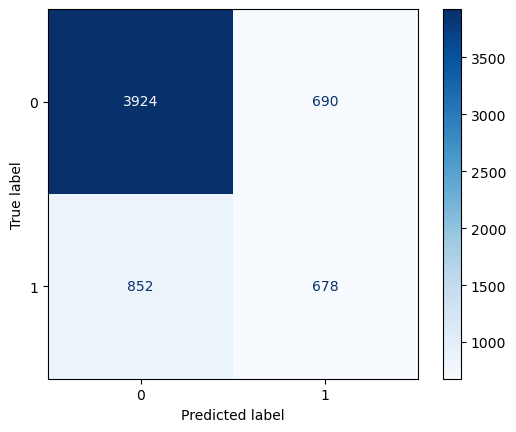

In [26]:
knn_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=knn_grid,
    X=X_test,
    y=y_test,
    display_labels=[0, 1],
    cmap=plt.cm.Blues
)

plt.show()

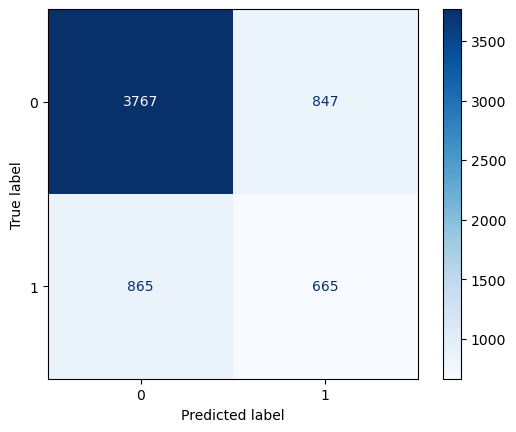

In [27]:
dt_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=fr_grid,
    X=X_test,
    y=y_test,
    display_labels=[0, 1],
    cmap=plt.cm.Blues
)

plt.show()

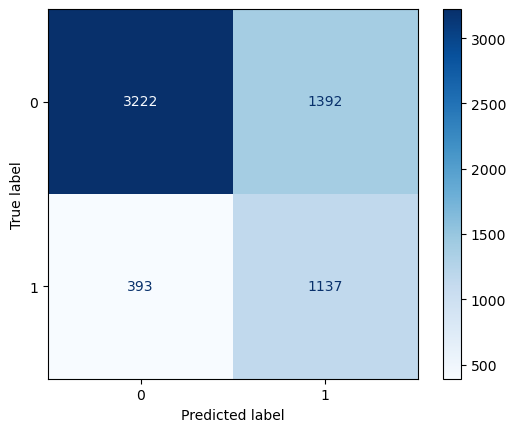

In [28]:
logistic_disp = ConfusionMatrixDisplay.from_estimator(
    estimator=logistic_grid,
    X=X_test,
    y=y_test,
    display_labels=[0, 1],
    cmap=plt.cm.Blues
)

plt.show()

In [30]:
y_pred_knn = knn_grid.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84      4614
           1       0.50      0.44      0.47      1530

    accuracy                           0.75      6144
   macro avg       0.66      0.65      0.65      6144
weighted avg       0.74      0.75      0.74      6144



In [34]:
accuracy_score(y_test, y_pred_knn)

0.7490234375

In [36]:
precision_score(y_test, y_pred_knn)

0.4956140350877193

In [39]:
recall_score(y_test, y_pred_knn)

0.44313725490196076

In [40]:
f1_score(y_test, y_pred_knn)

0.46790890269151136

In [31]:
y_pred_dt = fr_grid.predict(X_test)
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      4614
           1       0.44      0.43      0.44      1530

    accuracy                           0.72      6144
   macro avg       0.63      0.63      0.63      6144
weighted avg       0.72      0.72      0.72      6144



In [32]:
y_pred_logistic = logistic_grid.predict(X_test)
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.89      0.70      0.78      4614
           1       0.45      0.74      0.56      1530

    accuracy                           0.71      6144
   macro avg       0.67      0.72      0.67      6144
weighted avg       0.78      0.71      0.73      6144

